In [1]:
import mne 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from mne.datasets import eegbci

In [3]:
# 1. fetch file paths (run 1: resting state, run 4: motor imagery)
file_paths = eegbci.load_data(subjects=1, runs=[1, 4])

# 2. read resting state data into python
raw_rest = mne.io.read_raw_edf(file_paths[0], preload=True)

# 3. read active state data 
raw_active = mne.io.read_raw_edf(file_paths[1], preload=True)

print(f"resting data matrix shape: {raw_rest.get_data().shape}")
print(f"sampling freq: {raw_rest.info['sfreq']} Hz")

Extracting EDF parameters from /Users/pakachira/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Extracting EDF parameters from /Users/pakachira/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
resting data matrix shape: (64, 9760)
sampling freq: 160.0 Hz


In [4]:
import sys
sys.path.append('./src') # points to src directory
from preprocessing import butter_bandpass_filter 

# Filter resting-state signal matrix
filtered_rest = butter_bandpass_filter(
    data=raw_rest.get_data(),
    lowcut=8.0,
    highcut=30.0,
    fs=raw_rest.info['sfreq'],
    order=4
)

print(f"Raw Matrix Shape:      {raw_rest.get_data().shape}")
print(f"Filtered Matrix Shape: {filtered_rest.shape}")

Raw Matrix Shape:      (64, 9760)
Filtered Matrix Shape: (64, 9760)


In [5]:
# extract voltage array and time stamps
data, times = raw_rest.get_data(return_times=True)

# convert to dataframe (channels as columns, time points as rows)
df = pd.DataFrame(data.T, # transpose matrix for rows as time points and columns as channels
                  index=pd.Index(times, name="Time (s)"),
                  columns=raw_rest.ch_names)

# display first 5 rows of the dataframe
df.head()


,Fc5.,Fc3.,Fc1.,Fcz.,Fc2.,Fc4.,Fc6.,C5..,C3..,C1..,...,P8..,Po7.,Po3.,Poz.,Po4.,Po8.,O1..,Oz..,O2..,Iz..
Time (s),,,,,,,,,,,,,,,,,,,,,
0.00000,-0.000016,-0.000029,0.000002,0.000022,-0.000012,-0.000023,-0.000046,-0.000036,-0.000026,-0.000018,...,-0.000030,-0.000056,-0.000052,-0.000035,-0.000022,-0.000033,-0.000053,-0.000021,-0.000011,0.000015
0.00625,-0.000056,-0.000054,-0.000027,-0.000004,-0.000031,-0.000036,-0.000056,-0.000075,-0.000055,-0.000043,...,-0.000020,-0.000035,-0.000029,-0.000018,-0.000003,-0.000009,-0.000053,-0.000012,0.000001,0.000021
0.01250,-0.000055,-0.000055,-0.000029,-0.000005,-0.000029,-0.000034,-0.000052,-0.000053,-0.000042,-0.000035,...,-0.000020,-0.000023,-0.000012,-0.000006,0.000004,-0.000007,-0.000045,0.000002,0.000018,0.000035
0.01875,-0.000050,-0.000044,-0.000013,0.000013,-0.000016,-0.000025,-0.000045,-0.000044,-0.000021,-0.000011,...,-0.000016,-0.000012,0.000004,0.000014,0.000020,0.000007,-0.000029,0.000016,0.000035,0.000047
0.02500,-0.000036,-0.000028,0.000013,0.000042,0.000009,-0.000010,-0.000046,-0.000034,-0.000012,0.000008,...,-0.000009,-0.000007,0.000006,0.000020,0.000024,0.000006,-0.000013,0.000029,0.000040,0.000050


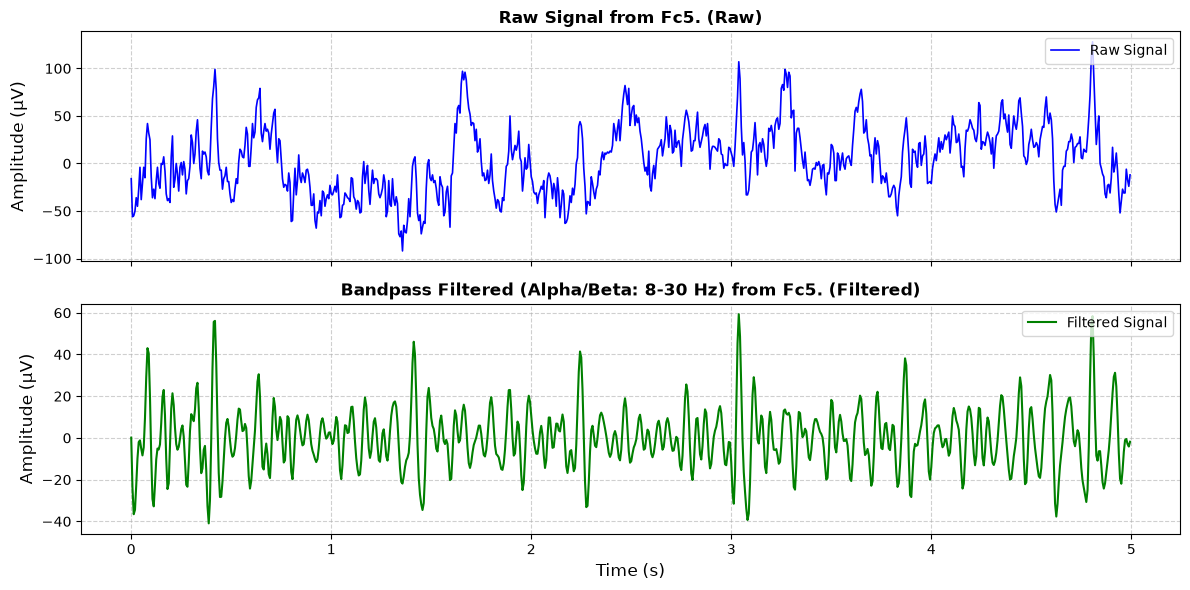

In [6]:
from visualization import plot_eeg_signal

# pick channel 0 (Fc5.)
channel_index = 0
channel_name = raw_rest.ch_names[channel_index]

times = raw_rest.times
raw_trace = raw_rest.get_data()[channel_index]
filtered_trace = filtered_rest[channel_index]

# Plot first 5 seconds
fig, axes = plot_eeg_signal(
    time=times,
    raw_signal=raw_trace,
    filtered_signal=filtered_trace,
    channel_name=channel_name,
    duration=5.0,
    fs=raw_rest.info['sfreq']
)

plt.show()

Mean Alpha Band Power across channels: 23.64 uV^2 / Hz


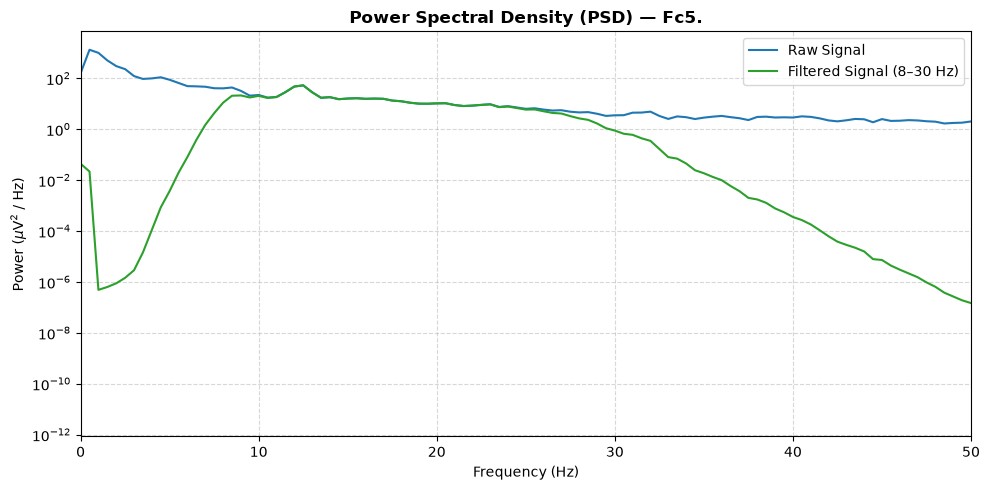

In [7]:
from features import compute_psd, extract_band_power
from visualization import plot_psd_comparison

# 1. compute PSD matrices for raw and filtered signals matrices
freqs, raw_psd = compute_psd(raw_rest.get_data(), fs=raw_rest.info['sfreq'])
_, filtered_psd = compute_psd(filtered_rest, fs=raw_rest.info['sfreq'])

# 2. extract avg. Alpha power (8-12 Hz) across all 64 channels
alpha_power = extract_band_power(freqs, filtered_psd, band_limits=(8.0, 12.0))
print(f"Mean Alpha Band Power across channels: {alpha_power.mean() * 1e12:.2f} uV^2 / Hz")

# 3. Plot PSD comparison for channel Fc5.
fig, ax = plot_psd_comparison(
    freqs=freqs,
    raw_psd=raw_psd,
    filtered_psd=filtered_psd,
    channel_idx=0,
    channel_name=raw_rest.ch_names[0]
)

plt.show()

In [8]:
from preprocessing import fit_ica, apply_ica_cleaning

# 1. Fit ICA model on resting state data
ica = fit_ica(raw_rest, n_components=15)

# 2. Automatically find blink artifacts using EOG or frontal channel correlations
# (Using electrode 'Fc5.' or frontal proxies if EOG isn't explicitly labeled)
eog_indices, eog_scores = ica.find_bads_eog(raw_rest, ch_name='Fc1.')

print(f"Identified Artifact Components: {eog_indices}")

# 3. Apply ICA cleaning to zero out identified ocular components
raw_cleaned = apply_ica_cleaning(raw_rest, ica, exclude_components=eog_indices)

Use rng= instead of random_state= in new code
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components


/Users/pakachira/Documents/eeg-lfp-signal-pipeline/./src/preprocessing.py:54: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_inst)


Fitting ICA took 2.7s.
Using EOG channel: Fc1.
... filtering ICA sources
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1600 samples (10.000 s)

... filtering target
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff

Extracting EDF parameters from /Users/pakachira/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Use rng= instead of random_state= in new code
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 15 components


/var/folders/mm/kpw6mjmx6fg41mf70_hr0_nh0000gn/T/ipykernel_29153/2797869506.py:11: FutureWarning: Montage name 'standard_1020' is deprecated and will be removed in MNE 1.14. Use 'colin27_1020' instead.
  montage = mne.channels.make_standard_montage("standard_1020")
/Users/pakachira/Documents/eeg-lfp-signal-pipeline/./src/preprocessing.py:54: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_inst)


Fitting ICA took 1.9s.


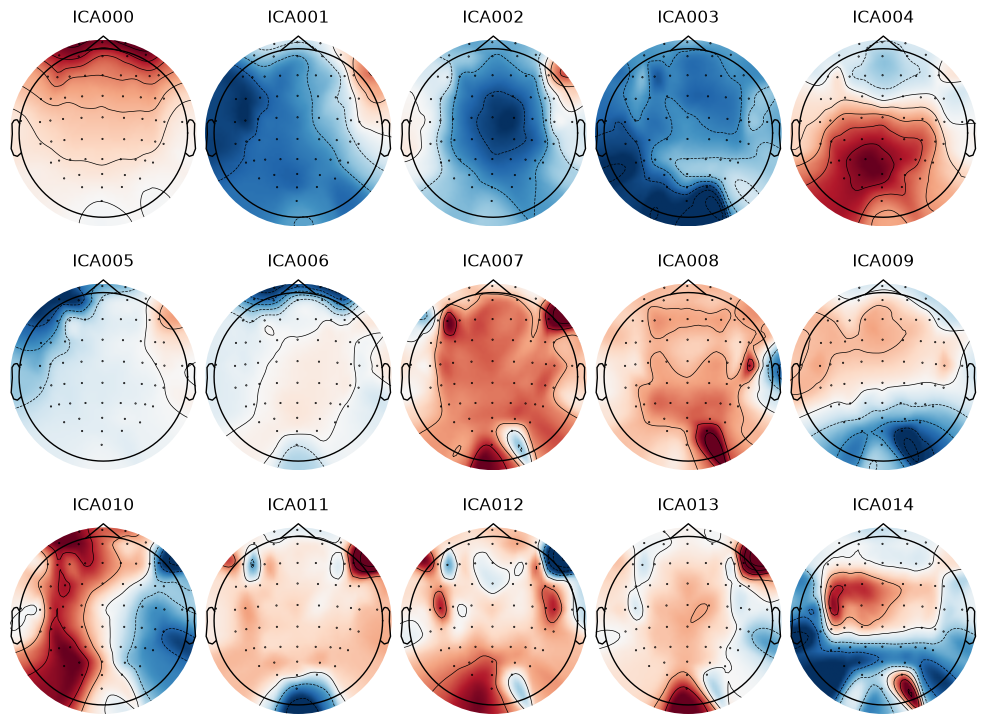

In [9]:
# MNE topographical plotting function needs 2D or 3D electrode positions (montage) 
# to project the scalp map.

# load fresh raw data from PhysioNet needed to prevent value error from MNE montage lookup converting name formatting
file_paths = mne.datasets.eegbci.load_data(subjects=1, runs=[1, 4])
raw_rest = mne.io.read_raw_edf(file_paths[0], preload=True)
# standardizer to clean channel names
mne.datasets.eegbci.standardize(raw_rest)

# 1. attach standard 10-20 electrode spatial map
montage = mne.channels.make_standard_montage("standard_1020")
raw_rest.set_montage(montage, on_missing="ignore") # MNE montage lookup is case-insensitive -> recognized Fc5 as FC5

# 2. fit ICA model on resting state data (now with spatial montage attached)
ica = fit_ica(raw_rest, n_components=15)

# 3. Plot topographies (now has 2D spatial coordinates!) across scalp map
ica.plot_components();


Applying ICA to Raw instance
    Transforming to ICA space (15 components)
    Zeroing out 1 ICA component
    Projecting back using 64 PCA components


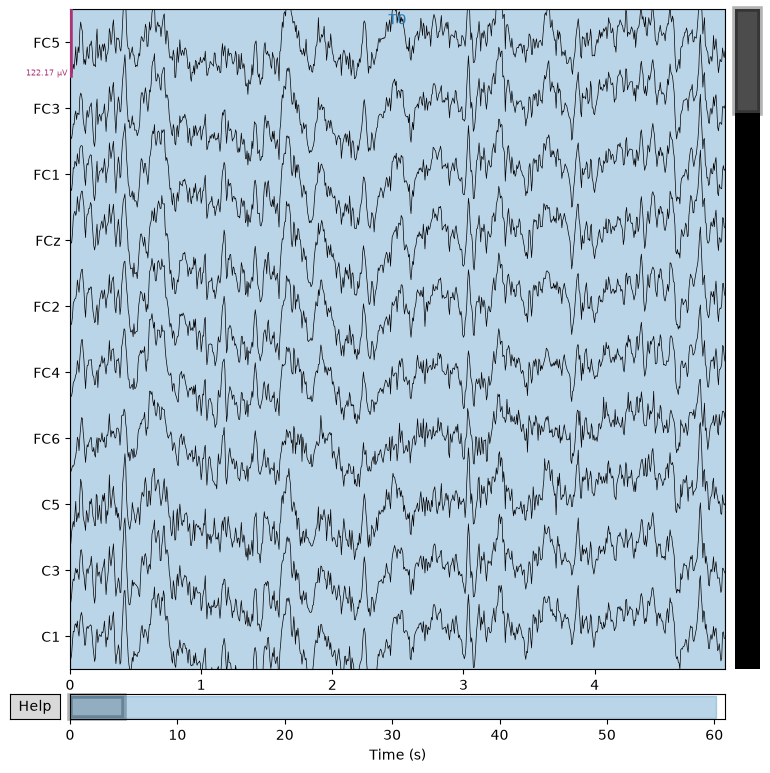

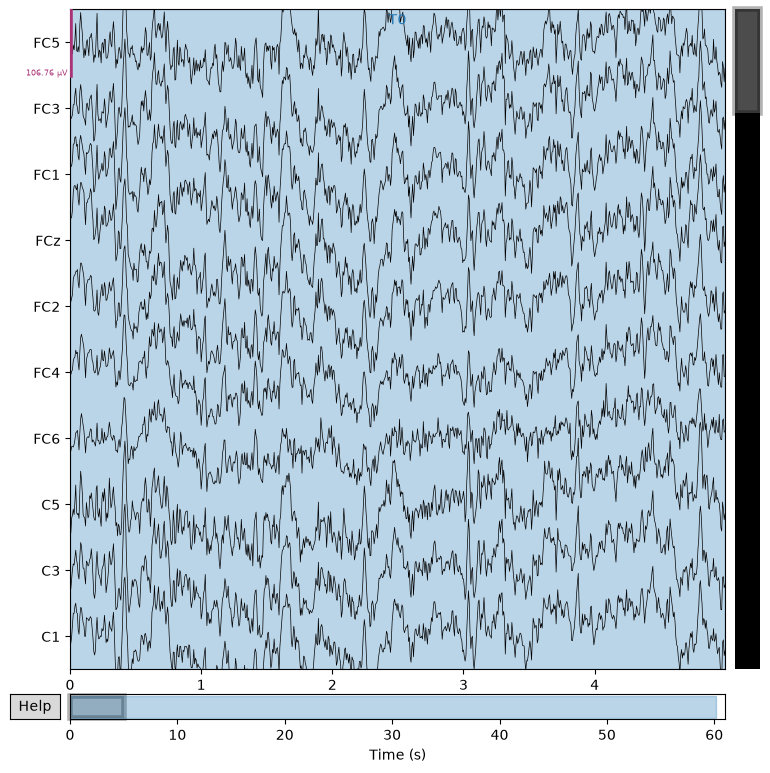

In [12]:
mne.viz.set_browser_backend('matplotlib')  # Set the backend to matplotlib for plotting

# zero out the primary eye blink component (ICA000)
eog_indices = [0]
# reconstructraw signals without ocular artifacts
raw_cleaned = apply_ica_cleaning(raw_rest, ica, exclude_components=eog_indices)

# time series before and after ICA cleaning for channel Fc5.
fig1 = raw_rest.plot(duration=5, n_channels=10, scalings='auto', title='Raw EEG Signal (with Ocular Artifacts)')
fig2 =raw_cleaned.plot(duration=5, n_channels=10, scalings='auto', title='Cleaned EEG Signal (ICA)')